# Задача 1

Написать модуль Self Attention'а.

1. Формула операции обычного Attention и 'скелет' модуля прилагаются.
2. Модуль принимает в конструкторе параметр d - это Hidden Size.
3. Входной тензор имеет размерность [Sequence, Hidden Size].
4. Выходной тензор ожидается, что будет тоже иметь размерность [Sequence, Hidden Size].
5. Проекции для Q, K, V, выхода должны быть, и причем обучаемыми.
6. Можно пользовать документацией PyTorch, кроме документации к Attention-модулям :).

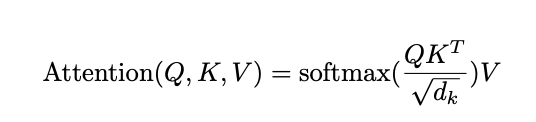

In [ ]:
import numpy as np


"""
The dot product torch.matmul(q_val, k_t) will have a standard deviation that is
a function of the input standard deviation and the number of dimensions (self.dim).
Specifically, the variance of the dot product will be proportional to self.dim,
making the standard deviation proportional to sqrt(self.dim).

"""

matA = np.random.randn(256, 512)
matB = np.random.randn(256, 512)

matmul = matA @ matB.T
D1 = matA.shape[1]**0.5
matnul_D1 = matmul/D1
print("D1:", D1)
print("std matA:",     np.round(matA.std()))
print("std matB",      np.round(matB.std()))
print("std matmul",    np.round(matmul.std()))
print("std matnul_D1", np.round(matnul_D1.std(), 3))

D1: 22.627416997969522
std matA: 1.0
std matB 1.0
std matmul 23.0
std matnul_D1 0.998


In [ ]:
matmul.shape

(256, 256)

In [ ]:
import torch
from torch import nn



class Attention(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.dim = dim

    self.q_w = nn.Linear(self.dim, self.dim)
    self.k_w = nn.Linear(self.dim, self.dim)
    self.v_w = nn.Linear(self.dim, self.dim)
    self.softmax = nn.Softmax(dim=-1)

    nn.init.xavier_normal_(self.q_w.weight)
    nn.init.xavier_normal_(self.k_w.weight)
    nn.init.xavier_normal_(self.v_w.weight)

  def forward(self,x):
    """
    x = batch, length, dim
    """
    q, k, v = self.q_w(x), self.k_w(x), self.v_w(x)
    k_t = k.transpose(-1, -2)
    score = q @ k_t/torch.sqrt(torch.tensor(self.dim))
    print("score std", score.std())
    score = self.softmax(score)
    v = score @ v
    return v

# x = torch.randn(2, 77, 512)
# print("init std: ",x.std())
# attn = DotAttention(512)
# res = attn(x)
# print("res seq:", res.size())

x = torch.Tensor([[[0.1, 0.2, 0.3], [0.9, 0.2, -1]]])
(print(x.size()))
attn = Attention(3)
res = attn(x)
print("res seq:", res)



torch.Size([1, 2, 3])
score std tensor(0.6646, grad_fn=<StdBackward0>)
res seq: tensor([[[ 0.0352, -0.3353, -0.0873],
         [ 0.0635, -0.1872, -0.0708]]], grad_fn=<UnsafeViewBackward0>)


In [ ]:
import torch
from torch import nn

"""
https://towardsdatascience.com/build-your-own-transformer-from-scratch-using-pytorch-84c850470dcb
"""

class MultyHeadDotAttention(nn.Module):
  def __init__(self, dim, num_heads):
    super().__init__()
    assert dim % num_heads == 0, "dim % num_heads != 0 !"

    self.dim = dim
    self.num_heads = num_heads
    self.d_k = dim // num_heads

    self.q_w = nn.Linear(self.dim, self.dim)
    self.k_w = nn.Linear(self.dim, self.dim)
    self.v_w = nn.Linear(self.dim, self.dim)
    self.out_w = nn.Linear(self.dim, self.dim)

    nn.init.xavier_normal_(self.q_w.weight)
    nn.init.xavier_normal_(self.k_w.weight)
    nn.init.xavier_normal_(self.v_w.weight)
    nn.init.xavier_normal_(self.out_w.weight)

    self.softmax = nn.Softmax(dim=-1)

  def split_heads(self,x):
    batch, length, dim = x.size()
    x = x.view(batch, length, self.num_heads, self.d_k)
    return x.transpose(2, 1)

  def combine_heads(self,x):
     batch, num_heds, length, dim = x.size()
     x = x.transpose(1, 2)
     return x.reshape(batch, length, self.dim)

  def scaled_dot_product(self, q, k, v):
    k_t = k.transpose(-1, -2)
    score = q @ k_t/torch.sqrt(torch.tensor(self.dim))
    print(f"size of q: {q.size()}")
    print(f"size of k: {k.size()}")
    print(f"dot score std: {score.std().item():.02f}")
    score = self.softmax(score)
    output = score @ v
    return output

  def forward(self,x):
    q, k, v = self.q_w(x), self.k_w(x), self.v_w(x)
    print("pure q:",q.size())

    q = self.split_heads(q)
    k = self.split_heads(k)
    v = self.split_heads(v)

    attn_out = self.scaled_dot_product(q,k,v)
    attn_out_combine = self.combine_heads(attn_out)
    out = self.out_w(attn_out_combine)
    return out

"""
x = batch, length, dim
"""
x = torch.randn(2, 77, 512)
print("init std: ",x.std())
attn = MultyHeadDotAttention(512, 8)
res = attn(x)
print("res seq:", res.size())

# x = torch.Tensor([[[0.1, 0.2, 0.3], [0.9, 0.2, -1]]])
# attn = DotAttention(3)
# res = attn(x)
# print("res seq:", res)



init std:  tensor(0.9974)
pure q: torch.Size([2, 77, 512])
Q.size: torch.Size([2, 8, 77, 64])
size of q: torch.Size([2, 8, 77, 64])
size of k: torch.Size([2, 8, 77, 64])
dot score std: 0.12
res seq: torch.Size([2, 77, 512])


In [ ]:
import numpy as np

"""
например возьмем два числа 100 и 90
разница между ними не такая большая
и кажется что softmax покажется числа около 0.8 и 0.2
но из-за того, что тут экспонента значения получатся
на тысяцу порядков больше и при e^100 и e^90
90 просто потеряется в 100 и получится 0
"""
softmax = nn.Softmax(dim=0)
out = softmax(torch.Tensor([100, 90]))
out.to(torch.float16).numpy()

"""
то же самое с numpy e^i/sum(e^i)
"""
i1 = (np.exp(90)/(np.exp(100) + np.exp(90)))
i2 = (np.exp(100)/(np.exp(100) + np.exp(90)))

print(np.round(i1, 2))
print(np.round(i2, 2))



0.0
1.0
